In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("churn-bigml-80.csv")

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [ ]:
df.shape

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


In [ ]:
churn_percent = df['Churn'].value_counts(normalize=True) * 100

for label, percent in churn_percent.items():
    status = 'Churned' if label else 'Stayed'
    print(f"{status}: {percent:.2f}%")

Stayed: 85.45%
Churned: 14.55%


In [ ]:
df['State'].unique()

array(['KS', 'OH', 'NJ', 'OK', 'AL', 'MA', 'MO', 'WV', 'RI', 'IA', 'MT',
       'ID', 'VT', 'VA', 'TX', 'FL', 'CO', 'AZ', 'NE', 'WY', 'IL', 'NH',
       'LA', 'GA', 'AK', 'MD', 'AR', 'WI', 'OR', 'DE', 'IN', 'UT', 'CA',
       'SD', 'NC', 'WA', 'MN', 'NM', 'NV', 'DC', 'NY', 'KY', 'ME', 'MS',
       'MI', 'SC', 'TN', 'PA', 'HI', 'ND', 'CT'], dtype=object)

In [ ]:
state_region_map = {
    # West
    'CA': 'West', 'OR': 'West', 'WA': 'West', 'NV': 'West',
    'ID': 'West', 'MT': 'West', 'WY': 'West', 'CO': 'West',
    'UT': 'West', 'AZ': 'West', 'NM': 'West', 'AK': 'West', 'HI': 'West',

    # Midwest
    'IL': 'Midwest', 'IN': 'Midwest', 'IA': 'Midwest', 'KS': 'Midwest',
    'MI': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest',
    'ND': 'Midwest', 'OH': 'Midwest', 'SD': 'Midwest', 'WI': 'Midwest',

    # South
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South',
    'NC': 'South', 'SC': 'South', 'VA': 'South', 'DC': 'South',
    'WV': 'South', 'AL': 'South', 'KY': 'South', 'MS': 'South',
    'TN': 'South', 'AR': 'South', 'LA': 'South', 'OK': 'South', 'TX': 'South',

    # Northeast
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast',
    'NH': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast',
    'PA': 'Northeast', 'RI': 'Northeast', 'VT': 'Northeast',
}

In [ ]:
df['region'] = df['State'].map(state_region_map)

In [ ]:
df['region'].value_counts()

,count
region,
South,906
West,665
Midwest,633
Northeast,462


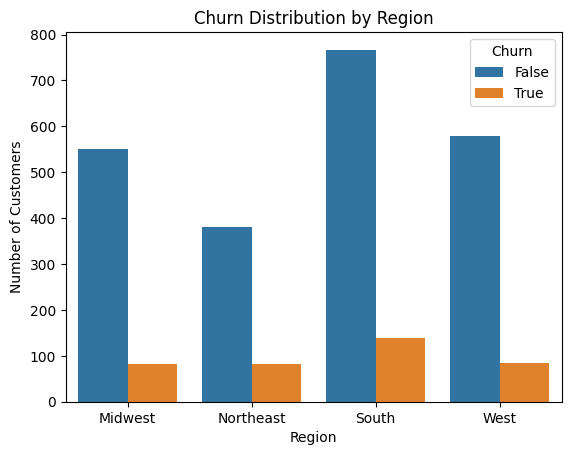

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Count of customers by region and churn
sns.countplot(x='region', hue='Churn', data=df)
plt.title('Churn Distribution by Region')
plt.xlabel('Region')
plt.ylabel('Number of Customers')
plt.legend(title='Churn')
plt.show()

In [ ]:
# Calculate total call duration in minutes
df['total_call_minutes'] = (
    df['Total day minutes'] +
    df['Total eve minutes'] +
    df['Total night minutes'] +
    df['Total intl minutes']
)

In [ ]:
# Calculate total number of calls
df['total_calls'] = (
    df['Total day calls'] +
    df['Total eve calls'] +
    df['Total night calls'] +
    df['Total intl calls']
)

In [ ]:
# Calculate total charges from all periods
df['total_charges'] = (
    df['Total day charge'] +
    df['Total eve charge'] +
    df['Total night charge'] +
    df['Total intl charge']
)

In [ ]:
df['active_plans_count'] = (
    df['International plan'].map({'Yes': 1, 'No': 0}) +
    df['Voice mail plan'].map({'Yes': 1, 'No': 0})
)

In [ ]:
# Count active plans per customer (0–2)
print(df['active_plans_count'].value_counts())

active_plans_count
0    1738
1     853
2      75
Name: count, dtype: int64


/tmp/ipython-input-14-1693672127.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='active_plans_count', palette='Set2')


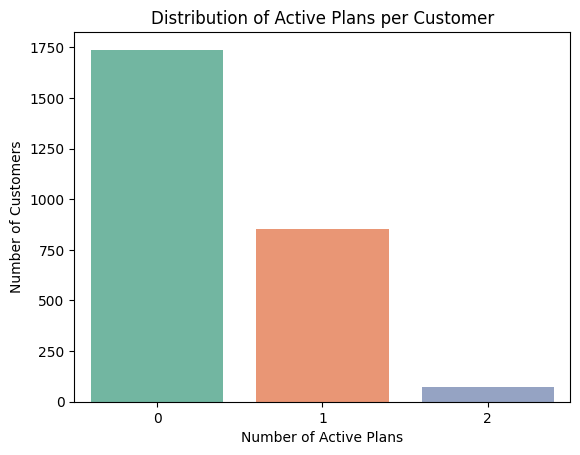

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=df, x='active_plans_count', palette='Set2')
plt.title('Distribution of Active Plans per Customer')
plt.xlabel('Number of Active Plans')
plt.ylabel('Number of Customers')
plt.show()

In [ ]:
# Categorize account length into tenure groups
def account_tenure_category(length):
    if length < 50:
        return 'Short-term'
    elif length < 100:
        return 'Mid-term'
    else:
        return 'Long-term'

df['tenure_category'] = df['Account length'].apply(account_tenure_category)

In [ ]:
# Flag frequent customer service calls
df['frequent_support_calls'] = df['Customer service calls'].apply(lambda x: 1 if x > 3 else 0)

In [ ]:
# Calculate the percentage of international call minutes out of total call minutes
df['intl_usage_rate'] = df['Total intl minutes'] / df['total_call_minutes']

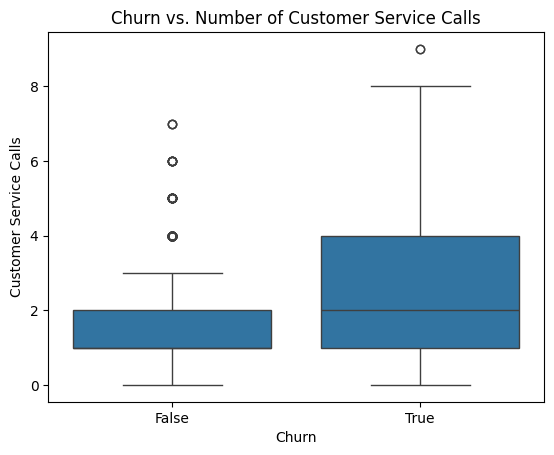

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x='Churn', y='Customer service calls', data=df)
plt.title('Churn vs. Number of Customer Service Calls')
plt.xlabel('Churn')
plt.ylabel('Customer Service Calls')
plt.show()

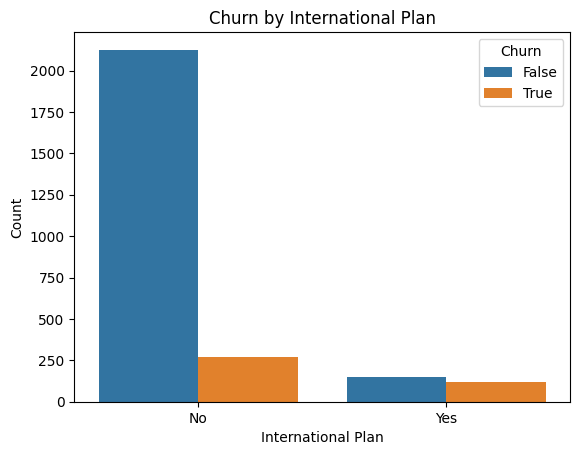

In [ ]:
sns.countplot(x='International plan', hue='Churn', data=df)
plt.title('Churn by International Plan')
plt.xlabel('International Plan')
plt.ylabel('Count')
plt.legend(title='Churn')
plt.show()

In [ ]:
df.shape

(2666, 28)

In [ ]:
df

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,...,Customer service calls,Churn,region,total_call_minutes,total_calls,total_charges,active_plans_count,tenure_category,frequent_support_calls,intl_usage_rate
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,...,1,False,Midwest,717.2,303,75.56,1,Long-term,0,0.013943
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,...,1,False,Midwest,625.2,332,59.24,1,Long-term,0,0.021913
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,...,0,False,Northeast,539.4,333,62.29,0,Long-term,0,0.022618
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,...,2,False,Midwest,564.8,255,66.80,1,Mid-term,0,0.011686
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,...,3,False,South,512.0,359,52.09,1,Mid-term,0,0.019727
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2661,SC,79,415,No,No,0,134.7,98,22.90,189.7,...,2,False,South,557.6,299,52.17,0,Mid-term,0,0.021162
2662,AZ,192,415,No,Yes,36,156.2,77,26.55,215.5,...,2,False,West,660.7,292,60.10,1,Long-term,0,0.014984
2663,WV,68,415,No,No,0,231.1,57,39.29,153.4,...,3,False,South,585.4,239,63.53,0,Mid-term,0,0.016399
2664,RI,28,510,No,No,0,180.8,109,30.74,288.8,...,2,False,Northeast,675.6,264,67.74,0,Short-term,0,0.020870


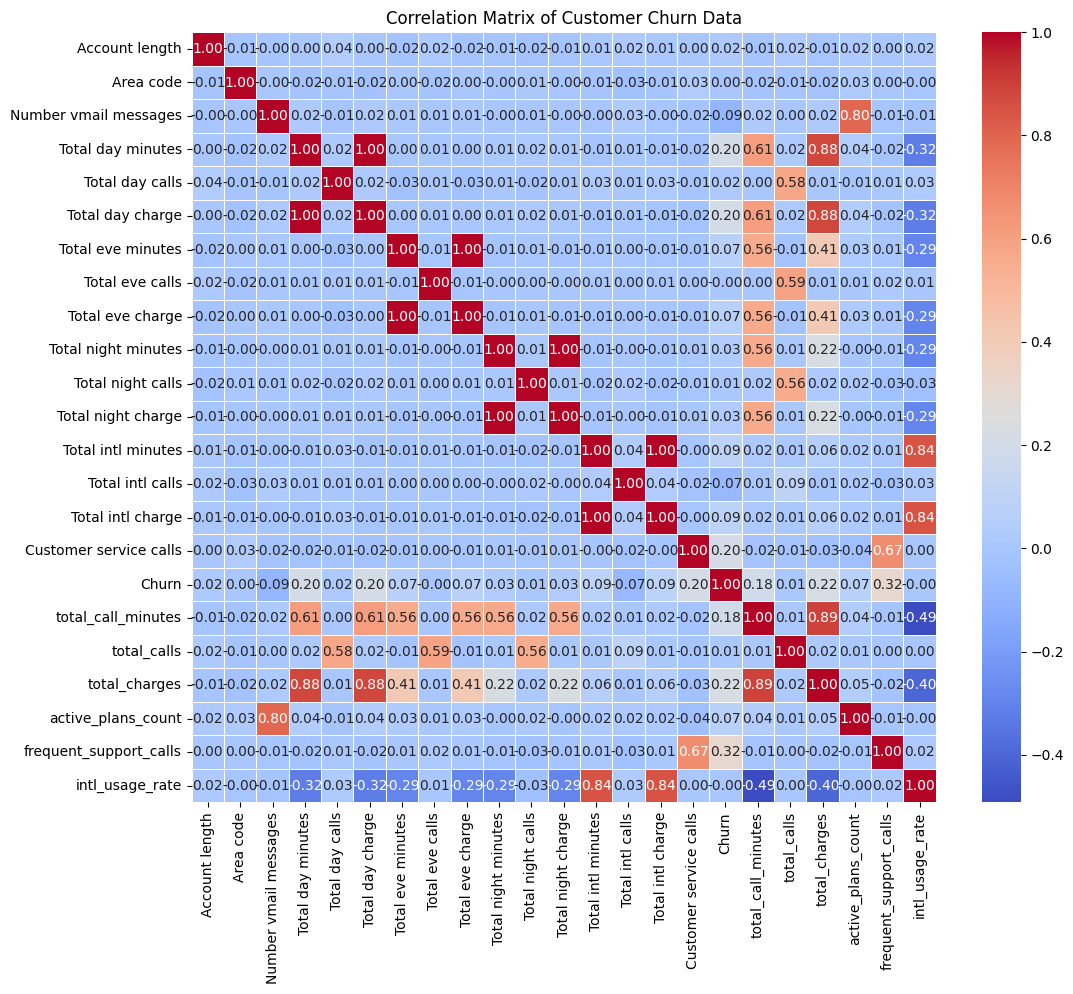

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr(numeric_only=True)

# Plot the heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix of Customer Churn Data')
plt.show()

In [ ]:
df['active_plans_count'].value_counts()

,count
active_plans_count,
0,1738
1,853
2,75


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pandas as pd



In [ ]:
X = df.drop(['Churn', 'State'], axis=1)
y = df['Churn']


In [ ]:
X_encoded = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)


In [ ]:
X_encoded.shape

(2666, 29)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

model = RandomForestClassifier(random_state=42)
model.fit(X_train_resampled, y_train_resampled)

Before SMOTE:
Churn
False    1823
True      309
Name: count, dtype: int64

After SMOTE:
Churn
False    1823
True     1823
Name: count, dtype: int64


RandomForestClassifier(random_state=42)

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE

X_encoded = X.copy()
for col in X_encoded.columns:
    if X_encoded[col].dtype == 'object':
        le = LabelEncoder()
        X_encoded[col] = le.fit_transform(X_encoded[col])

X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_resampled.value_counts())

model = RandomForestClassifier(random_state=42, class_weight='balanced')
model.fit(X_train_resampled, y_train_resampled)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Before SMOTE:
Churn
False    1822
True      310
Name: count, dtype: int64

After SMOTE:
Churn
False    1822
True     1822
Name: count, dtype: int64

Accuracy: 0.9456928838951311

Confusion Matrix:
 [[450   6]
 [ 23  55]]

Classification Report:
               precision    recall  f1-score   support

       False       0.95      0.99      0.97       456
        True       0.90      0.71      0.79        78

    accuracy                           0.95       534
   macro avg       0.93      0.85      0.88       534
weighted avg       0.94      0.95      0.94       534



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_resampled)
X_test_scaled = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=2000, class_weight='balanced'),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight='balanced')
}

for name, model in models.items():
    print(f"\n====== {name} ======")

    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train_resampled)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train_resampled, y_train_resampled)
        y_pred = model.predict(X_test)


    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))



====== Logistic Regression ======
Accuracy: 0.7678
Confusion Matrix:
[[361  95]
 [ 29  49]]
Classification Report:
              precision    recall  f1-score   support

       False       0.93      0.79      0.85       456
        True       0.34      0.63      0.44        78

    accuracy                           0.77       534
   macro avg       0.63      0.71      0.65       534
weighted avg       0.84      0.77      0.79       534


====== K-Nearest Neighbors ======
Accuracy: 0.6685
Confusion Matrix:
[[317 139]
 [ 38  40]]
Classification Report:
              precision    recall  f1-score   support

       False       0.89      0.70      0.78       456
        True       0.22      0.51      0.31        78

    accuracy                           0.67       534
   macro avg       0.56      0.60      0.55       534
weighted avg       0.80      0.67      0.71       534


====== Random Forest ======
Accuracy: 0.9457
Confusion Matrix:
[[450   6]
 [ 23  55]]
Classification Report:
    

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score
import pandas as pd


results = {}

for name, model in models.items():
    print(f"\n====== {name} ======")

    if name in ["Logistic Regression", "K-Nearest Neighbors"]:
        y_pred = model.predict(X_test_scaled)
    else:
        y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results[name] = {
        "Accuracy": acc,
        "Recall": rec,
        "Precision": prec,
        "F1-Score": f1
    }

results_df = pd.DataFrame(results).T
results_df = results_df.round(4)

print("\n--- Model Performance Summary ---")
print(results_df)

best_model_name = results_df["Accuracy"].idxmax()
best_model_score = results_df.loc[best_model_name, "Accuracy"]

print(f"\nBest Model: {best_model_name} with Accuracy = {best_model_score:.4f}")



====== Logistic Regression ======

====== K-Nearest Neighbors ======

====== Random Forest ======


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(



--- Model Performance Summary ---
                     Accuracy  Recall  Precision  F1-Score
Logistic Regression    0.6217  0.5641     0.2075    0.3034
K-Nearest Neighbors    0.1461  1.0000     0.1461    0.2549
Random Forest          0.9457  0.7051     0.9016    0.7914

Best Model: Random Forest with Accuracy = 0.9457
